Load processed bioaccessibility data

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

BASE_DIR = Path.cwd()

if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

data_path = BASE_DIR / "data" / "processed_data" / "processed_bioaccessibility.csv"
fig_dir = BASE_DIR / "figures"
result_dir = BASE_DIR / "results"

fig_dir.mkdir(exist_ok=True)
result_dir.mkdir(exist_ok=True)

processed_bio = pd.read_csv(data_path, encoding="utf-8-sig")

print(processed_bio.shape)
processed_bio.head()

(190, 18)


,Number,Site,Type,Method,pH,SOM,Clay,Silt,Sand,Fe,T_Cd,GP,IP,BA_GP,BA_IP,log_T_Cd,log_GP,log_IP
0,1.0,西南某矿区土壤重金属的人体生物有效性及健康风险评估,Mining/smelting soils,SBRC,6.98,27.99,1.70,48.20,50.10,33.150080,2.91,0.908502,0.704511,31.22,24.21,1.363537,0.646319,0.533278
1,1.0,西南某矿区土壤重金属的人体生物有效性及健康风险评估,Mining/smelting soils,SBRC,6.07,73.91,0.02,36.36,63.62,66.904483,2.06,0.791452,0.555582,38.42,26.97,1.118415,0.583026,0.441850
2,1.0,西南某矿区土壤重金属的人体生物有效性及健康风险评估,Mining/smelting soils,SBRC,5.87,43.02,0.65,25.98,73.37,37.976127,1.25,0.631875,0.554000,50.55,44.32,0.810930,0.489730,0.440832
3,1.0,西南某矿区土壤重金属的人体生物有效性及健康风险评估,Mining/smelting soils,SBRC,6.01,66.52,0.51,19.77,79.71,67.569832,1.68,0.588336,0.523824,35.02,31.18,0.985817,0.462687,0.421223
4,1.0,西南某矿区土壤重金属的人体生物有效性及健康风险评估,Mining/smelting soils,SBRC,5.75,46.44,0.02,22.20,77.78,63.906229,2.39,0.580531,0.544442,24.29,22.78,1.220830,0.457761,0.434663


Calculate observed bioaccessible Cd

In [2]:
risk_data = processed_bio.dropna(subset=["T_Cd", "BA_GP"]).copy()

risk_data["Observed_Bioaccessible_Cd_GP"] = (
    risk_data["T_Cd"] * risk_data["BA_GP"] / 100
)

risk_data[
    ["T_Cd", "BA_GP", "Observed_Bioaccessible_Cd_GP"]
].head()

,T_Cd,BA_GP,Observed_Bioaccessible_Cd_GP
0,2.91,31.22,0.908502
1,2.06,38.42,0.791452
2,1.25,50.55,0.631875
3,1.68,35.02,0.588336
4,2.39,24.29,0.580531


 Predict BA_GP using full Random Forest model

In [3]:
target = "BA_GP"

numeric_features = [
    "pH", "SOM", "Clay", "Silt", "Sand",
    "Fe", "log_T_Cd"
]

categorical_features = ["Method", "Type"]

risk_features = numeric_features + categorical_features

model_data = processed_bio.dropna(subset=[target, "T_Cd"]).copy()

X_model = model_data[risk_features]
y_model = model_data[target]

In [4]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

rf_risk_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        min_samples_leaf=3
    ))
])

from sklearn.model_selection import KFold, cross_val_predict

cv = KFold(n_splits=5, shuffle=True, random_state=42)

model_data["Predicted_BA_GP"] = cross_val_predict(
    rf_risk_model,
    X_model,
    y_model,
    cv=cv
)

In [6]:
# 防止预测值超过 0–100 的合理范围
model_data["Predicted_BA_GP"] = model_data["Predicted_BA_GP"].clip(0, 100)

model_data[["BA_GP", "Predicted_BA_GP"]].head()

,BA_GP,Predicted_BA_GP
0,31.22,58.126526
1,38.42,38.497952
2,50.55,51.606912
3,35.02,40.211934
4,24.29,48.885568


Calculate predicted bioaccessible Cd

In [7]:
model_data["Observed_Bioaccessible_Cd_GP"] = (
    model_data["T_Cd"] * model_data["BA_GP"] / 100
)

model_data["Predicted_Bioaccessible_Cd_GP"] = (
    model_data["T_Cd"] * model_data["Predicted_BA_GP"] / 100
)

model_data[
    [
        "T_Cd",
        "BA_GP",
        "Predicted_BA_GP",
        "Observed_Bioaccessible_Cd_GP",
        "Predicted_Bioaccessible_Cd_GP"
    ]
].head()

,T_Cd,BA_GP,Predicted_BA_GP,Observed_Bioaccessible_Cd_GP,Predicted_Bioaccessible_Cd_GP
0,2.91,31.22,58.126526,0.908502,1.691482
1,2.06,38.42,38.497952,0.791452,0.793058
2,1.25,50.55,51.606912,0.631875,0.645086
3,1.68,35.02,40.211934,0.588336,0.675560
4,2.39,24.29,48.885568,0.580531,1.168365


 Plot Compare total Cd vs bioaccessible Cd

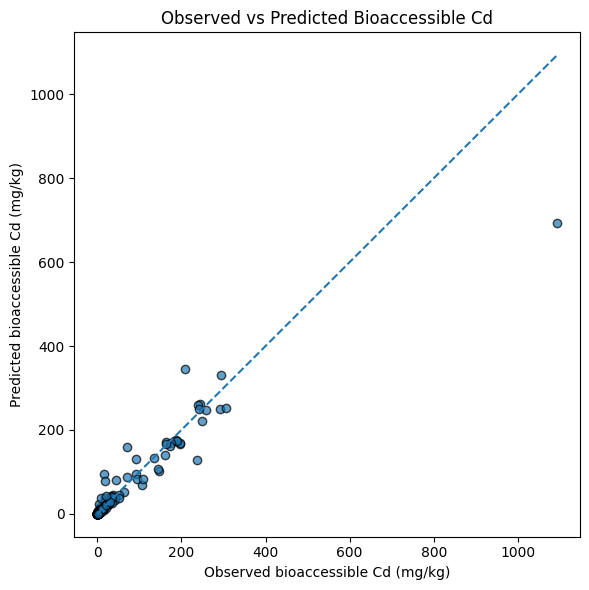

In [8]:
plt.figure(figsize=(6, 6))

plt.scatter(
    model_data["Observed_Bioaccessible_Cd_GP"],
    model_data["Predicted_Bioaccessible_Cd_GP"],
    alpha=0.7,
    edgecolor="black"
)

max_val = max(
    model_data["Observed_Bioaccessible_Cd_GP"].max(),
    model_data["Predicted_Bioaccessible_Cd_GP"].max()
)

plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlabel("Observed bioaccessible Cd (mg/kg)")
plt.ylabel("Predicted bioaccessible Cd (mg/kg)")
plt.title("Observed vs Predicted Bioaccessible Cd")
plt.tight_layout()
plt.savefig(fig_dir / "observed_vs_predicted_bioaccessible_cd_gp.png", dpi=300)
plt.show()

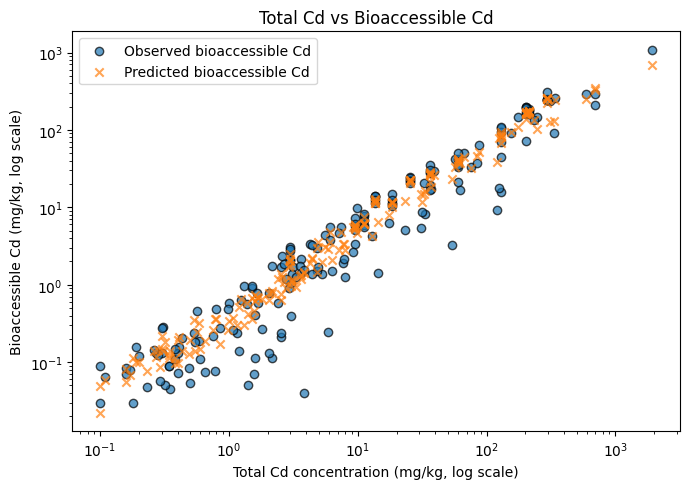

In [9]:
plt.figure(figsize=(7, 5))

plt.scatter(
    model_data["T_Cd"],
    model_data["Observed_Bioaccessible_Cd_GP"],
    alpha=0.7,
    edgecolor="black",
    label="Observed bioaccessible Cd"
)

plt.scatter(
    model_data["T_Cd"],
    model_data["Predicted_Bioaccessible_Cd_GP"],
    alpha=0.7,
    marker="x",
    label="Predicted bioaccessible Cd"
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Total Cd concentration (mg/kg, log scale)")
plt.ylabel("Bioaccessible Cd (mg/kg, log scale)")
plt.title("Total Cd vs Bioaccessible Cd")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "total_cd_vs_bioaccessible_cd_gp.png", dpi=300)
plt.show()

 Create Low / Medium / High risk groups

In [10]:
model_data["Predicted_Risk_Group"] = pd.qcut(
    model_data["Predicted_Bioaccessible_Cd_GP"],
    q=3,
    labels=["Low", "Medium", "High"]
)

model_data["Predicted_Risk_Group"].value_counts()

Predicted_Risk_Group
Low       64
Medium    63
High      63
Name: count, dtype: int64

Summarize risk groups by Type

In [11]:
risk_by_type = (
    model_data
    .groupby(["Type", "Predicted_Risk_Group"])
    .size()
    .reset_index(name="count")
)

risk_by_type["proportion"] = (
    risk_by_type
    .groupby("Type")["count"]
    .transform(lambda x: x / x.sum())
)

risk_by_type

,Type,Predicted_Risk_Group,count,proportion
0,Agricultural soils,Low,10,0.232558
1,Agricultural soils,Medium,19,0.441860
2,Agricultural soils,High,14,0.325581
3,Industrial soils,Low,18,0.439024
4,Industrial soils,Medium,7,0.170732
5,Industrial soils,High,16,0.390244
6,Mining/smelting soils,Low,29,0.367089
7,Mining/smelting soils,Medium,32,0.405063
8,Mining/smelting soils,High,18,0.227848
9,Urban soils,Low,7,0.259259


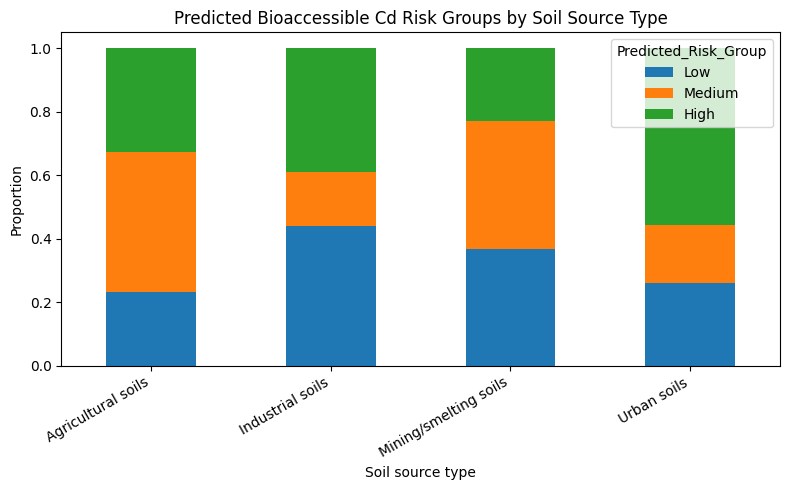

In [14]:
risk_pivot = risk_by_type.pivot(
    index="Type",
    columns="Predicted_Risk_Group",
    values="proportion"
).fillna(0)

risk_pivot = risk_pivot.reindex(columns=["Low", "Medium", "High"], fill_value=0)

risk_pivot.plot(kind="bar", stacked=True, figsize=(8, 5))

plt.ylabel("Proportion")
plt.xlabel("Soil source type")
plt.title("Predicted Bioaccessible Cd Risk Groups by Soil Source Type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(fig_dir / "predicted_bioaccessible_risk_by_type.png", dpi=300)
plt.show()

In [13]:
model_data.to_csv(
    result_dir / "bioaccessible_cd_risk_data.csv",
    index=False,
    encoding="utf-8-sig"
)

risk_by_type.to_csv(
    result_dir / "bioaccessible_cd_risk_by_type.csv",
    index=False,
    encoding="utf-8-sig"
)